# **EDA**

## Objectives
* Test each of the five hypotheses using an appropriate statistical test, and visualise the result.

## Inputs
* data/cleaned/cleaned_transactions.csv

## Outputs
* A chart and a statistical test result for each hypothesis, saved to outputs/figures/.

## Additional Comments
* All five hypotheses are reported here regardless of outcome - a hypothesis that isn't supported by the data is still a genuine finding, not something to leave out.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Fraud_Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Fraud_Analysis'

# Libraries Import

In [5]:
# Libraries being used in the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

In [10]:
os.makedirs('outputs/figures', exist_ok=True)

# Load the Cleaned Data

The cleaned dataset produced in the ETL notebook is loaded here, rather than the raw file, since
all of the cleaning and feature engineering needed for the hypothesis tests below has already been
done - including the Has_Prior_Fraud column engineered specifically for Hypothesis 1.

In [6]:
df = pd.read_csv('data/cleaned/cleaned_transactions.csv', parse_dates=['Timestamp'])
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Is_Outlier_Amount,Has_Prior_Fraud
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,3,Amex,65,883.17,Biometric,0.8494,0,0,False,False
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,4,Mastercard,186,2203.36,Password,0.0959,0,1,False,False
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,4,Visa,226,1909.29,Biometric,0.8400,0,1,False,False
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,4,Visa,76,1311.86,OTP,0.7935,0,1,False,False
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,4,Mastercard,140,966.98,Password,0.3819,1,1,False,True


# Statistics & Probability Primer

Before testing the hypotheses below, this is a short primer on the statistical concepts used and
why each one applies to the comparison it's used for.

- Mean and median describe the typical value of a numeric column. The median is used where a
  column is skewed, since a few very large values can pull the mean upward - this was the
  reasoning used for the median imputation decision in the ETL notebook.
- Probability: Fraud_Label is either 0 or 1, so its mean is literally the probability that
  any given transaction is fraud - 32.13%, established in the ETL notebook.
- A chi-square test checks whether two categorical variables are related, by comparing the
  counts actually observed in a table against the counts that would be expected if there were no
  relationship at all. Used below for H1, H2, and H3, since all three compare a categorical or
  binary variable against Fraud_Label.
- Welch's t-test compares the average of a numeric variable between two groups, without
  assuming the two groups have equal variance. Used for H4, comparing Transaction_Distance
  between fraud and non-fraud transactions.
- Point-biserial correlation measures the relationship between a numeric variable and a binary
  variable, and is specifically designed for that combination rather than a general correlation.
  Used for H5, comparing Failed_Transaction_Count_7d against Fraud_Label.
- A p-value below 0.05 is treated as statistically significant throughout this notebook -
  below that threshold, a result this strong is unlikely to have happened by chance alone if there
  were actually no real relationship.

#  Fraud Rate Overview

Before testing individual hypotheses, the overall class balance is checked, since this affects how
every later result should be read - if fraud were extremely rare, a strong-looking percentage
difference could still represent very few transactions.

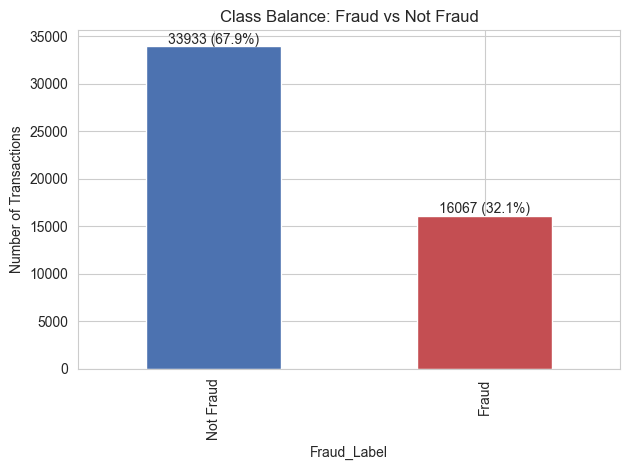

In [11]:
fraud_counts = df['Fraud_Label'].value_counts().rename({0: 'Not Fraud', 1: 'Fraud'})
ax = fraud_counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
ax.set_title('Class Balance: Fraud vs Not Fraud')
ax.set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts):
    ax.text(i, v + 300, f"{v} ({v/len(df):.1%})", ha='center')
plt.tight_layout()
plt.savefig('outputs/figures/01_class_balance.png', dpi=120)
plt.show()

Fraud makes up 32.13% of this dataset. This is a moderate imbalance, not the severe imbalance
often assumed in fraud detection write-ups, and is worth keeping in mind when interpreting the
hypothesis results below.

## Hypothesis 1: Prior Fraudulent Activity

H1: Accounts with prior fraudulent activity are more likely to commit fraud again.

This is a comparison between two categorical variables - whether an account has prior fraud on
record (the Has_Prior_Fraud column engineered in the ETL notebook), and whether the current
transaction is fraud. A chi-square test of independence is the appropriate test for this, since
both variables are categorical rather than numeric.

In [12]:
ct1 = pd.crosstab(df['Has_Prior_Fraud'], df['Fraud_Label'])
chi2, p, dof, expected = stats.chi2_contingency(ct1)
print(ct1)
print(f"Chi-square: {chi2:.3f}, p-value: {p:.4f}")

Fraud_Label          0      1
Has_Prior_Fraud              
False            30589  14491
True              3344   1576
Chi-square: 0.021, p-value: 0.8851


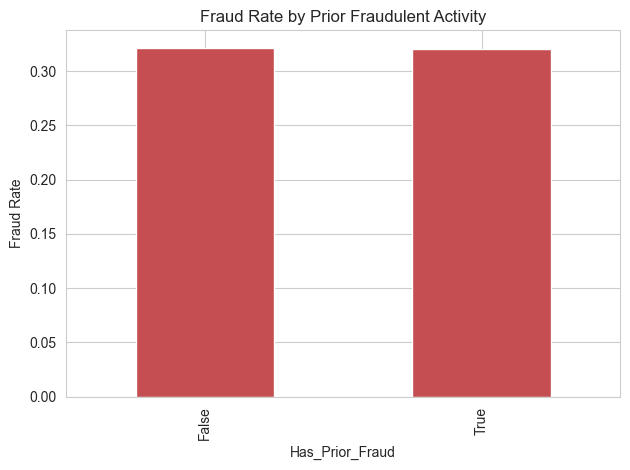

In [13]:
rate_by_history = df.groupby('Has_Prior_Fraud')['Fraud_Label'].mean()
ax = rate_by_history.plot(kind='bar', color='#C44E52')
ax.set_title('Fraud Rate by Prior Fraudulent Activity')
ax.set_ylabel('Fraud Rate')
plt.tight_layout()
plt.savefig('outputs/figures/02_fraud_rate_by_prior_activity.png', dpi=120)
plt.show()

The chi-square test returns p = 0.8851, well above the 0.05 threshold. The fraud rate is almost
identical whether or not an account has prior fraudulent activity on record - 32.1% either way.
H1 is not supported by this dataset.

## Hypothesis 2: Authentication Method

H2: Fraud rate differs by authentication method.

Authentication_Method has four categories in this dataset (Biometric, OTP, PIN, Password), so
the chi-square test compares fraud rate across all four groups at once, rather than just two.

In [14]:
ct2 = pd.crosstab(df['Authentication_Method'], df['Fraud_Label'])
chi2, p, dof, expected = stats.chi2_contingency(ct2)
print(ct2)
print(f"Chi-square: {chi2:.3f}, p-value: {p:.4f}")

Fraud_Label               0     1
Authentication_Method            
Biometric              8553  4038
OTP                    8345  4021
PIN                    8608  3978
Password               8427  4030
Chi-square: 2.729, p-value: 0.4354


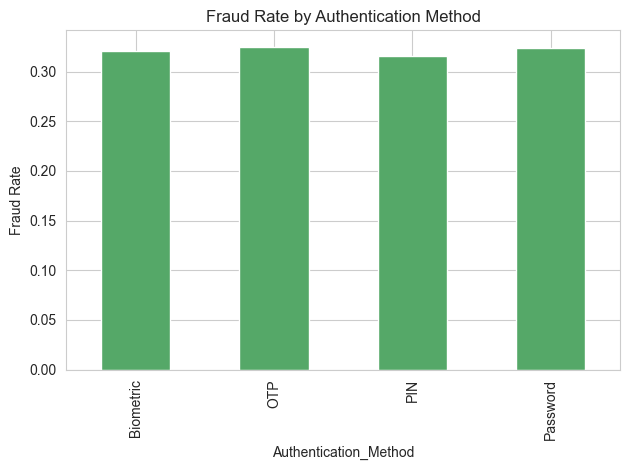

In [15]:
auth_rate = df.groupby('Authentication_Method')['Fraud_Label'].mean()
ax = auth_rate.plot(kind='bar', color='#55A868')
ax.set_title('Fraud Rate by Authentication Method')
ax.set_ylabel('Fraud Rate')
plt.tight_layout()
plt.savefig('outputs/figures/03_fraud_rate_by_auth_method.png', dpi=120)
plt.show()

The chi-square test returns p = 0.4354. Fraud rate sits close to 32% for every authentication
method, with no meaningful difference between them. H2 is not supported by this dataset.

---

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
